# SC-OTS v2: Simplicial-Constrained Oblique Tree Sums

**Elastic Net Splits and Adaptive Stopping**

This notebook demonstrates the SC-OTS v2 pipeline:

1. **Distance Correlation** -- Compute pairwise distance correlation matrix between features
2. **Vietoris-Rips Filtration** -- Build simplicial complex via GUDHI persistent homology
3. **Persistence Threshold Selection** -- Cross-validated threshold for feature grouping
4. **MI-Based Simplex Filtering** -- Filter higher-order simplices using mutual information
5. **SC-OTS Model** -- Oblique tree sums constrained to simplex feature groups
6. **Baseline Comparison** -- FIGS, XGBoost, XGBoost+constraints, EBM

The pipeline is benchmarked on the Friedman1 synthetic regression dataset.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('dcor==0.6')
_pip('gudhi==3.10.1')
_pip('imodels==1.4.4')
_pip('interpret==0.6.10')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         'scipy==1.16.3', 'matplotlib==3.10.0', 'xgboost==3.1.3',
         'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imodels 1.4.4 requires pandas<=2.1.4, but you have pandas 2.2.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import time
import warnings
from pathlib import Path

import dcor
import gudhi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor, Ridge
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from tabulate import tabulate

warnings.filterwarnings("ignore")

## Data Loading

Load the Friedman1 demo dataset from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-f5f9f2-simplicial-constrained-oblique-tree-sums/main/experiment_iter3_sc_ots_v2_simpl/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  friedman1: 80 examples


## Configuration

All tunable parameters for the SC-OTS pipeline. Values are set for a quick demo run.

In [5]:
# ── SC-OTS Pipeline Parameters ──
MAX_SAMPLES_DCOR = 2000        # subsample for dCor computation
MAX_SPLITS_SCOTS = 30          # max oblique splits for SC-OTS
VAL_PATIENCE = 3               # early stopping patience
L1_RATIO = 0.85                # elastic net L1 ratio
ALPHA = 0.001                  # elastic net alpha
MI_THRESHOLD_RATIO = 0.10      # MI excess threshold for simplex filtering
MAX_DIM_RIPS = 3               # max simplicial dimension
MAX_SCOTS_TIME_PER_FOLD = 120  # seconds time limit per fold
MAX_SCOTS_TRAIN_SAMPLES = 5000 # subsample training for SC-OTS

# ── Baseline Parameters ──
FIGS_MAX_RULES_CANDIDATES = [5, 10, 15, 20, 30]

# ── Experiment Parameters ──
N_FOLDS = 5                    # number of CV folds to run
MAX_DATASETS = 1               # process only the first dataset

## Parse Dataset

Parse the raw JSON into numpy arrays for processing.

In [6]:
def parse_dataset(raw_data, max_datasets=1):
    """Parse the benchmark dataset JSON into numpy arrays."""
    datasets = {}
    for ds_entry in raw_data["datasets"][:max_datasets]:
        ds_name = ds_entry["dataset"]
        examples = ds_entry["examples"]
        if len(examples) == 0:
            continue

        ex0 = examples[0]
        task_type = ex0["metadata_task_type"]
        n_features = ex0["metadata_n_features"]

        feature_names = ex0.get("metadata_feature_names", [f"f{i}" for i in range(n_features)])
        if len(feature_names) < n_features:
            feature_names = [f"f{i}" for i in range(n_features)]

        known_interactions_str = ex0.get("metadata_known_interactions", None)
        known_interactions = None
        if known_interactions_str:
            try:
                known_interactions = json.loads(known_interactions_str)
            except (json.JSONDecodeError, TypeError):
                known_interactions = None

        X_list, y_list, folds_list = [], [], []
        for ex in examples:
            inp = json.loads(ex["input"])
            X_list.append(inp)
            if task_type == "classification":
                y_list.append(int(ex["output"]))
            else:
                y_list.append(float(ex["output"]))
            folds_list.append(int(ex["metadata_fold"]))

        X = np.array(X_list, dtype=np.float64)
        y = np.array(y_list, dtype=np.float64)
        folds = np.array(folds_list, dtype=int)

        datasets[ds_name] = {
            "X": X, "y": y, "folds": folds,
            "task_type": task_type, "n_features": n_features,
            "feature_names": feature_names,
            "known_interactions": known_interactions,
            "n_samples": len(examples),
            "category": ex0.get("metadata_category", "unknown"),
        }
        print(f"  {ds_name}: n={X.shape[0]}, p={X.shape[1]}, task={task_type}")

    print(f"Parsed {len(datasets)} dataset(s)")
    return datasets

datasets = parse_dataset(data, max_datasets=MAX_DATASETS)

  friedman1: n=80, p=10, task=regression
Parsed 1 dataset(s)


## Step 1: Distance Correlation Matrix

Compute pairwise distance correlation between features. For high-dimensional data (>40 features), falls back to absolute Pearson correlation.

In [7]:
def compute_dcor_matrix(X: np.ndarray) -> np.ndarray:
    """Compute pairwise distance correlation matrix.

    Subsample if dataset is too large for performance.
    For very wide datasets (>40 features), use abs(Pearson) as a fast fallback.
    """
    n_samples, n_features = X.shape

    # For very wide datasets, use Pearson correlation as fast fallback
    if n_features > 40:
        print(f"    Using Pearson correlation fallback for {n_features} features")
        corr = np.corrcoef(X.T)
        corr = np.nan_to_num(corr, nan=0.0)
        return np.abs(corr)

    # Subsample for speed
    if n_samples > MAX_SAMPLES_DCOR:
        rng = np.random.RandomState(42)
        idx = rng.choice(n_samples, size=MAX_SAMPLES_DCOR, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X

    dcor_matrix = np.eye(n_features)
    for i in range(n_features):
        for j in range(i + 1, n_features):
            try:
                dc = dcor.distance_correlation(X_sub[:, i], X_sub[:, j])
                if not np.isfinite(dc):
                    dc = 0.0
            except Exception:
                dc = 0.0
            dcor_matrix[i, j] = dc
            dcor_matrix[j, i] = dc

    return dcor_matrix


def dcor_to_dissimilarity(dcor_matrix: np.ndarray) -> np.ndarray:
    """Convert distance correlation to dissimilarity: sqrt(1 - dCor)."""
    clipped = np.clip(dcor_matrix, 0.0, 1.0)
    return np.sqrt(1.0 - clipped)

## Step 2: Vietoris-Rips Filtration & Persistent Homology

Build a Rips complex from the dissimilarity matrix and compute persistent homology using GUDHI.

In [8]:
def build_rips_persistence(
    dissimilarity_matrix: np.ndarray,
    max_dim: int = 3,
) -> tuple:
    """Build Rips complex from dissimilarity matrix and compute persistence."""
    n = dissimilarity_matrix.shape[0]

    # Convert to lower-triangular list format for GUDHI
    lower_tri = []
    for i in range(n):
        row = []
        for j in range(i):
            row.append(float(dissimilarity_matrix[i, j]))
        lower_tri.append(row)

    rips = gudhi.RipsComplex(
        distance_matrix=lower_tri,
        max_edge_length=1.0,
    )
    simplex_tree = rips.create_simplex_tree(max_dimension=max_dim)
    persistence = simplex_tree.persistence()

    return simplex_tree, persistence

## Step 3: Persistence Threshold Selection

Select the optimal persistence threshold via internal cross-validation using a fast proxy model.

In [9]:
def extract_persistent_simplices(
    simplex_tree: gudhi.SimplexTree,
    persistence: list,
    min_persistence: float,
) -> dict:
    """Extract simplices from the complex at a filtration level
    determined by persistent features above the threshold."""
    birth_values = []
    for dim, (birth, death) in persistence:
        if dim >= 1 and np.isfinite(death) and (death - birth) >= min_persistence:
            birth_values.append(death)

    if not birth_values:
        all_filts = [filt for simplex, filt in simplex_tree.get_skeleton(1)
                     if len(simplex) == 2]
        if all_filts:
            eps = float(np.median(all_filts))
        else:
            eps = 0.5
    else:
        eps = max(birth_values)

    st_copy = gudhi.SimplexTree()
    for simplex, filt in simplex_tree.get_simplices():
        st_copy.insert(simplex, filtration=filt)
    st_copy.prune_above_filtration(eps)

    simplices_by_dim = {0: [], 1: [], 2: [], 3: []}
    for simplex, filt in st_copy.get_simplices():
        dim = len(simplex) - 1
        if dim in simplices_by_dim:
            simplices_by_dim[dim].append(tuple(simplex))

    return simplices_by_dim


def select_persistence_threshold(
    X_train: np.ndarray,
    y_train: np.ndarray,
    simplex_tree: gudhi.SimplexTree,
    persistence: list,
    task_type: str,
    n_internal_folds: int = 2,
) -> float:
    """Select persistence threshold via internal CV with fast proxy model."""
    all_persistence_values = []
    for dim, (birth, death) in persistence:
        if dim >= 1 and np.isfinite(death):
            pers_val = death - birth
            if pers_val > 0:
                all_persistence_values.append(pers_val)

    if len(all_persistence_values) == 0:
        return 0.0

    all_persistence_values = np.array(all_persistence_values)

    candidates = [
        float(np.percentile(all_persistence_values, 20)),
        float(np.percentile(all_persistence_values, 40)),
        float(np.percentile(all_persistence_values, 60)),
        float(np.percentile(all_persistence_values, 80)),
    ]

    sorted_pers = np.sort(all_persistence_values)
    if len(sorted_pers) >= 2:
        gaps = np.diff(sorted_pers)
        gap_idx = int(np.argmax(gaps))
        gap_threshold = float((sorted_pers[gap_idx] + sorted_pers[gap_idx + 1]) / 2)
        candidates.append(gap_threshold)

    candidates = sorted(set(candidates))

    best_score = -np.inf
    best_threshold = candidates[len(candidates) // 2]

    n_sub = min(X_train.shape[0], 2000)
    if X_train.shape[0] > n_sub:
        rng = np.random.RandomState(42)
        idx = rng.choice(X_train.shape[0], size=n_sub, replace=False)
        X_sub = X_train[idx]
        y_sub = y_train[idx]
    else:
        X_sub = X_train
        y_sub = y_train

    kf = KFold(n_splits=n_internal_folds, shuffle=True, random_state=42)

    for threshold in candidates:
        scores = []
        for train_idx, val_idx in kf.split(X_sub):
            X_tr, X_val = X_sub[train_idx], X_sub[val_idx]
            y_tr, y_val = y_sub[train_idx], y_sub[val_idx]

            simplices = extract_persistent_simplices(
                simplex_tree, persistence, min_persistence=threshold
            )

            all_features = set()
            for d in [1, 2, 3]:
                for s in simplices.get(d, []):
                    all_features.update(s)
            if not all_features:
                all_features = set(range(X_train.shape[1]))
            feat_list = sorted(all_features)

            if task_type == "regression":
                proxy = DecisionTreeRegressor(max_depth=5, random_state=42)
            else:
                proxy = DecisionTreeClassifier(max_depth=5, random_state=42)
            proxy.fit(X_tr[:, feat_list], y_tr)
            score = proxy.score(X_val[:, feat_list], y_val)
            scores.append(score)

        mean_score = np.mean(scores)
        if mean_score > best_score:
            best_score = mean_score
            best_threshold = threshold

    return best_threshold

## Step 4: MI-Based Simplex Filtering

Filter higher-order simplices (dim 2, 3) by comparing joint vs individual mutual information. Only retains simplices where the feature group interaction exceeds the sum of individual contributions.

In [10]:
def filter_simplices_by_mi(
    simplices_by_dim: dict,
    X: np.ndarray,
    y: np.ndarray,
    task_type: str,
    mi_threshold_ratio: float = MI_THRESHOLD_RATIO,
) -> dict:
    """Filter higher-order simplices using decision tree score proxy for MI."""
    from sklearn.feature_selection import (
        mutual_info_classif,
        mutual_info_regression,
    )

    mi_func = mutual_info_classif if task_type == "classification" else mutual_info_regression

    n = min(X.shape[0], 2000)
    rng = np.random.RandomState(42)
    if X.shape[0] > n:
        idx = rng.choice(X.shape[0], size=n, replace=False)
        X_sub = X[idx]
        y_sub = y[idx]
    else:
        X_sub = X
        y_sub = y

    n_neighbors_mi = min(5, max(1, X_sub.shape[0] - 2))
    if n_neighbors_mi < 1 or X_sub.shape[0] < 5:
        return simplices_by_dim
    try:
        individual_mi = mi_func(X_sub, y_sub, random_state=42, n_neighbors=n_neighbors_mi)
    except ValueError:
        return simplices_by_dim

    filtered = {0: simplices_by_dim[0], 1: simplices_by_dim[1]}

    for dim in [2, 3]:
        filtered[dim] = []
        for simplex in simplices_by_dim.get(dim, []):
            feature_indices = list(simplex)

            if task_type == "regression":
                TreeModel = DecisionTreeRegressor
            else:
                TreeModel = DecisionTreeClassifier

            joint_tree = TreeModel(max_depth=3, random_state=42)
            joint_tree.fit(X_sub[:, feature_indices], y_sub)
            joint_score = joint_tree.score(X_sub[:, feature_indices], y_sub)

            sum_individual = sum(individual_mi[fi] for fi in feature_indices if fi < len(individual_mi))

            if sum_individual > 0 and (joint_score / sum_individual) >= (1 + mi_threshold_ratio):
                filtered[dim].append(simplex)
            elif sum_individual == 0 and joint_score > 0:
                filtered[dim].append(simplex)

    for dim in [2, 3]:
        before = len(simplices_by_dim.get(dim, []))
        after = len(filtered[dim])
        if before > 0:
            print(f"    MI filter dim {dim}: {before} -> {after} simplices "
                  f"({100 * (before - after) / before:.0f}% removed)")

    return filtered

## Step 5: SC-OTS Model

The core model: oblique tree sums where splits are constrained to feature groups from the simplicial complex. Uses elastic net (SGD) for oblique split directions and FIGS-style greedy tree growing with validation-based early stopping.

In [11]:
class ObliqueSplitNode:
    """A node in an oblique decision tree."""
    __slots__ = [
        "coefficients", "feature_indices", "threshold", "value",
        "left", "right", "impurity_reduction", "n_samples",
        "is_leaf", "tree_num", "depth",
    ]

    def __init__(self):
        self.coefficients = None
        self.feature_indices = None
        self.threshold = None
        self.value = 0.0
        self.left = None
        self.right = None
        self.impurity_reduction = 0.0
        self.n_samples = 0
        self.is_leaf = True
        self.tree_num = 0
        self.depth = 0

    def predict_single(self, x: np.ndarray) -> float:
        if self.is_leaf:
            return self.value
        projection = np.dot(x[self.feature_indices], self.coefficients)
        if projection <= self.threshold:
            return self.left.predict_single(x)
        else:
            return self.right.predict_single(x)


class SCOTSModel:
    """Simplicial-Constrained Oblique Tree Sum."""

    def __init__(
        self,
        simplices_by_dim: dict,
        task_type: str,
        max_splits: int = MAX_SPLITS_SCOTS,
        val_patience: int = VAL_PATIENCE,
        l1_ratio: float = L1_RATIO,
        alpha: float = ALPHA,
        time_limit: float = MAX_SCOTS_TIME_PER_FOLD,
    ):
        self.simplices_by_dim = simplices_by_dim
        self.task_type = task_type
        self.max_splits = max_splits
        self.val_patience = val_patience
        self.l1_ratio = l1_ratio
        self.alpha = alpha
        self.time_limit = time_limit
        self.trees_ = []
        self.n_splits_ = 0

    def _get_candidate_simplices(self) -> list:
        """Return all simplices as candidate feature groups."""
        candidates = []
        for dim in [1, 2, 3]:
            for simplex in self.simplices_by_dim.get(dim, []):
                candidates.append(list(simplex))
        for simplex in self.simplices_by_dim.get(0, []):
            candidates.append(list(simplex))
        return candidates

    def _fit_oblique_split(self, X, y, sample_mask, feature_indices):
        """Fit an oblique split on the given feature subset."""
        X_sub = X[sample_mask][:, feature_indices]
        y_sub = y[sample_mask]
        n = X_sub.shape[0]

        if n < 10:
            return None

        if len(feature_indices) == 1:
            stump = DecisionTreeRegressor(max_depth=1)
            stump.fit(X_sub, y_sub)
            if stump.tree_.feature[0] < 0:
                return None
            threshold = stump.tree_.threshold[0]
            coefficients = np.array([1.0])
            left_mask_local = X_sub[:, 0] <= threshold
        else:
            best_coefs = None
            for try_alpha in [self.alpha, self.alpha * 0.1, self.alpha * 0.01]:
                sgd = SGDRegressor(
                    penalty="elasticnet",
                    l1_ratio=self.l1_ratio,
                    alpha=try_alpha,
                    max_iter=1000,
                    tol=1e-4,
                    random_state=42,
                )
                try:
                    sgd.fit(X_sub, y_sub)
                    if not np.allclose(sgd.coef_, 0):
                        best_coefs = sgd.coef_.copy()
                        break
                except Exception:
                    continue

            if best_coefs is None:
                try:
                    ridge = Ridge(alpha=1.0)
                    ridge.fit(X_sub, y_sub)
                    best_coefs = ridge.coef_.copy()
                except Exception:
                    return None
                if np.allclose(best_coefs, 0):
                    return None

            coefficients = best_coefs
            norm = np.linalg.norm(coefficients)
            if norm > 0:
                coefficients = coefficients / norm

            projections = X_sub @ coefficients
            candidate_thresholds = np.percentile(projections, [25, 50, 75])

            best_impurity_reduction = -np.inf
            best_threshold = candidate_thresholds[1]
            total_var = np.var(y_sub) * n
            left_mask_local = projections <= best_threshold

            for t in candidate_thresholds:
                left_local = projections <= t
                right_local = ~left_local
                n_left = int(left_local.sum())
                n_right = int(right_local.sum())
                if n_left < 5 or n_right < 5:
                    continue
                impurity_left = np.var(y_sub[left_local]) * n_left
                impurity_right = np.var(y_sub[right_local]) * n_right
                reduction = total_var - impurity_left - impurity_right
                if reduction > best_impurity_reduction:
                    best_impurity_reduction = reduction
                    best_threshold = t
                    left_mask_local = left_local

            threshold = best_threshold

        sample_indices = np.where(sample_mask)[0]
        global_left_mask = np.zeros(len(X), dtype=bool)
        global_right_mask = np.zeros(len(X), dtype=bool)
        global_left_mask[sample_indices[left_mask_local]] = True
        global_right_mask[sample_indices[~left_mask_local]] = True

        y_parent = y[sample_mask]
        y_left = y[global_left_mask]
        y_right = y[global_right_mask]
        if len(y_left) == 0 or len(y_right) == 0:
            return None
        impurity_parent = np.var(y_parent) * len(y_parent)
        impurity_left = np.var(y_left) * len(y_left)
        impurity_right = np.var(y_right) * len(y_right)
        impurity_reduction = impurity_parent - impurity_left - impurity_right

        return (coefficients, threshold, impurity_reduction,
                global_left_mask, global_right_mask, feature_indices)

    def fit(self, X, y, X_val=None, y_val=None):
        """Greedy FIGS-style tree sum with oblique splits and validation stopping."""
        fit_start = time.time()
        n, p = X.shape
        candidate_simplices = self._get_candidate_simplices()

        if len(candidate_simplices) == 0:
            candidate_simplices = [[i] for i in range(p)]

        if len(candidate_simplices) > 50:
            by_dim = sorted(candidate_simplices, key=lambda s: -len(s))
            candidate_simplices = by_dim[:50]

        if n > MAX_SCOTS_TRAIN_SAMPLES:
            rng = np.random.RandomState(42)
            sub_idx = rng.choice(n, size=MAX_SCOTS_TRAIN_SAMPLES, replace=False)
            X_fit = X[sub_idx]
            y_fit = y[sub_idx].copy()
            n_fit = MAX_SCOTS_TRAIN_SAMPLES
        else:
            X_fit = X
            y_fit = y.copy()
            n_fit = n

        self.trees_ = []
        residuals = y_fit.copy().astype(float)
        n_splits = 0
        best_val_score = -np.inf
        patience_counter = 0
        n_trees_to_grow = max(1, self.max_splits // 5)

        for tree_idx in range(n_trees_to_grow):
            elapsed = time.time() - fit_start
            if elapsed > self.time_limit:
                break

            root = ObliqueSplitNode()
            root.value = float(np.mean(residuals))
            root.is_leaf = True
            root.n_samples = n_fit
            root.tree_num = tree_idx

            potential_leaves = [(root, np.ones(n_fit, dtype=bool))]
            splits_this_tree = 0
            max_splits_per_tree = min(5, self.max_splits - n_splits)

            for _ in range(max_splits_per_tree):
                if time.time() - fit_start > self.time_limit:
                    break

                best_split = None
                best_reduction = -np.inf
                best_leaf_idx = -1

                for leaf_idx, (leaf_node, mask) in enumerate(potential_leaves):
                    if mask.sum() < 10:
                        continue
                    for simplex_features in candidate_simplices:
                        if max(simplex_features) >= p:
                            continue
                        result = self._fit_oblique_split(X_fit, residuals, mask, simplex_features)
                        if result is None:
                            continue
                        coefs, thresh, reduction, left_m, right_m, feats = result
                        if reduction > best_reduction:
                            best_reduction = reduction
                            best_split = result
                            best_leaf_idx = leaf_idx

                if best_split is None or best_reduction <= 0:
                    break

                coefs, thresh, reduction, left_m, right_m, feats = best_split
                leaf_node, mask = potential_leaves[best_leaf_idx]

                leaf_node.is_leaf = False
                leaf_node.coefficients = coefs
                leaf_node.threshold = thresh
                leaf_node.feature_indices = feats

                left_child = ObliqueSplitNode()
                left_child.value = float(np.mean(residuals[left_m])) if left_m.sum() > 0 else 0.0
                left_child.n_samples = int(left_m.sum())
                left_child.tree_num = tree_idx
                left_child.depth = leaf_node.depth + 1

                right_child = ObliqueSplitNode()
                right_child.value = float(np.mean(residuals[right_m])) if right_m.sum() > 0 else 0.0
                right_child.n_samples = int(right_m.sum())
                right_child.tree_num = tree_idx
                right_child.depth = leaf_node.depth + 1

                leaf_node.left = left_child
                leaf_node.right = right_child

                potential_leaves.pop(best_leaf_idx)
                potential_leaves.append((left_child, left_m))
                potential_leaves.append((right_child, right_m))

                n_splits += 1
                splits_this_tree += 1

            self.trees_.append(root)

            predictions = self._predict_array(X_fit)
            residuals = y_fit.astype(float) - predictions

            if X_val is not None and y_val is not None:
                val_preds = self.predict(X_val)
                if self.task_type == "regression":
                    var_y = np.var(y_val)
                    val_score = 1 - np.mean((y_val - val_preds) ** 2) / var_y if var_y > 0 else 0.0
                else:
                    try:
                        val_score = roc_auc_score(y_val, val_preds)
                    except ValueError:
                        val_score = accuracy_score(y_val, (val_preds > 0.5).astype(int))

                if val_score > best_val_score:
                    best_val_score = val_score
                    patience_counter = 0
                else:
                    patience_counter += 1

                if patience_counter >= self.val_patience:
                    break

            if splits_this_tree == 0:
                break

        self.n_splits_ = n_splits

    def _predict_array(self, X: np.ndarray) -> np.ndarray:
        predictions = np.zeros(X.shape[0])
        for tree_root in self.trees_:
            for i in range(X.shape[0]):
                predictions[i] += tree_root.predict_single(X[i])
        return predictions

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self._predict_array(X)

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        preds = self.predict(X)
        if self.task_type == "regression":
            var_y = np.var(y)
            return 1 - np.mean((y - preds) ** 2) / var_y if var_y > 0 else 0.0
        else:
            try:
                return roc_auc_score(y, preds)
            except ValueError:
                return accuracy_score(y, (preds > 0.5).astype(int))

## Step 6: Baseline Models

Fit comparison baselines: FIGS, XGBoost, XGBoost with simplicial interaction constraints, and EBM (Explainable Boosting Machine).

In [12]:
def fit_figs(X_train, y_train, X_val, y_val, X_test, task_type):
    """Fit FIGS baseline with max_rules selection."""
    from imodels import FIGSClassifier, FIGSRegressor

    best_score = -np.inf
    best_model = None
    best_mr = 10

    for mr in FIGS_MAX_RULES_CANDIDATES:
        try:
            if task_type == "classification":
                model = FIGSClassifier(max_rules=mr)
            else:
                model = FIGSRegressor(max_rules=mr)
            model.fit(X_train, y_train)
            preds_val = model.predict(X_val)
            if task_type == "regression":
                var_y = np.var(y_val)
                sc = 1 - np.mean((y_val - preds_val) ** 2) / var_y if var_y > 0 else 0.0
            else:
                try:
                    sc = roc_auc_score(y_val, preds_val)
                except ValueError:
                    sc = accuracy_score(y_val, preds_val)
            if sc > best_score:
                best_score = sc
                best_model = model
                best_mr = mr
        except Exception:
            continue

    if best_model is None:
        return {"score": 0.0, "total_splits": 0, "training_time_s": 0.0}

    if task_type == "classification" and hasattr(best_model, "predict_proba"):
        test_preds = best_model.predict_proba(X_test)[:, 1]
    else:
        test_preds = best_model.predict(X_test).astype(float)
    return {"predictions": test_preds, "model": best_model, "best_max_rules": best_mr}


def fit_xgboost_default(X_train, y_train, X_val, y_val, X_test, task_type):
    """Fit XGBoost baseline."""
    from xgboost import XGBClassifier, XGBRegressor

    if task_type == "classification":
        model = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            eval_metric="logloss", random_state=42,
            use_label_encoder=False, verbosity=0,
        )
    else:
        model = XGBRegressor(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            eval_metric="rmse", random_state=42, verbosity=0,
        )

    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    if task_type == "classification" and hasattr(model, "predict_proba"):
        test_preds = model.predict_proba(X_test)[:, 1]
    else:
        test_preds = model.predict(X_test).astype(float)
    return {"predictions": test_preds, "model": model}


def fit_xgboost_constrained(X_train, y_train, X_val, y_val, X_test, task_type, simplices_by_dim, n_features):
    """Fit XGBoost with simplicial interaction constraints."""
    from xgboost import XGBClassifier, XGBRegressor

    feat_names = [f"f{i}" for i in range(n_features)]
    X_train_df = pd.DataFrame(X_train, columns=feat_names)
    X_val_df = pd.DataFrame(X_val, columns=feat_names)
    X_test_df = pd.DataFrame(X_test, columns=feat_names)

    groups = []
    seen_features = set()
    for dim in [1, 2, 3]:
        for simplex in simplices_by_dim.get(dim, []):
            grp = [f"f{f}" for f in simplex if f < n_features]
            if grp:
                groups.append(grp)
                seen_features.update(int(f) for f in simplex if f < n_features)
    for f in range(n_features):
        if f not in seen_features:
            groups.append([f"f{f}"])

    if task_type == "classification":
        model = XGBClassifier(
            interaction_constraints=groups,
            n_estimators=100, max_depth=6, learning_rate=0.1,
            random_state=42, use_label_encoder=False, verbosity=0,
        )
    else:
        model = XGBRegressor(
            interaction_constraints=groups,
            n_estimators=100, max_depth=6, learning_rate=0.1,
            random_state=42, verbosity=0,
        )

    model.fit(X_train_df, y_train, eval_set=[(X_val_df, y_val)], verbose=False)
    if task_type == "classification" and hasattr(model, "predict_proba"):
        test_preds = model.predict_proba(X_test_df)[:, 1]
    else:
        test_preds = model.predict(X_test_df).astype(float)
    return {"predictions": test_preds, "model": model}


def fit_ebm(X_train, y_train, X_test, task_type):
    """Fit EBM (Explainable Boosting Machine) baseline."""
    from interpret.glassbox import (
        ExplainableBoostingClassifier,
        ExplainableBoostingRegressor,
    )

    if task_type == "classification":
        model = ExplainableBoostingClassifier(
            interactions=10, max_bins=256, outer_bags=4, random_state=42,
        )
    else:
        model = ExplainableBoostingRegressor(
            interactions=10, max_bins=256, outer_bags=4, random_state=42,
        )

    model.fit(X_train, y_train)
    if task_type == "classification" and hasattr(model, "predict_proba"):
        test_preds = model.predict_proba(X_test)[:, 1]
    else:
        test_preds = model.predict(X_test).astype(float)
    return {"predictions": test_preds, "model": model}

## Step 7: Evaluation Metrics & Experiment Loop

Compute predictive performance (R2 for regression, AUROC for classification) and interaction recovery metrics, then run the full pipeline on each dataset-fold combination.

In [13]:
def compute_score(y_true, y_pred, task_type):
    """Compute predictive performance score. Returns (score, metric_name, extra)."""
    y_pred = np.array(y_pred, dtype=float)
    y_true = np.array(y_true, dtype=float)

    if task_type == "regression":
        var_y = np.var(y_true)
        r2 = 1 - np.mean((y_true - y_pred) ** 2) / var_y if var_y > 0 else 0.0
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        return r2, "R2", rmse
    else:
        y_pred_binary = (y_pred > 0.5).astype(int)
        try:
            auc = roc_auc_score(y_true, y_pred)
            metric_name = "AUROC"
        except ValueError:
            auc = accuracy_score(y_true, y_pred_binary)
            metric_name = "accuracy"
        acc = accuracy_score(y_true, y_pred_binary)
        return auc, metric_name, acc


def parse_ground_truth_interactions(known_interactions):
    """Parse ground-truth interactions from metadata into frozensets."""
    gt = set()
    if known_interactions is None:
        return gt
    for key in ["2-way", "3-way", "4-way"]:
        if key in known_interactions:
            for group in known_interactions[key]:
                gt.add(frozenset(group))
    return gt


def compute_interaction_recovery(discovered_simplices, ground_truth_interactions):
    """Compute precision, recall, F1 for interaction recovery."""
    if not ground_truth_interactions:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    tp = len(discovered_simplices & ground_truth_interactions)
    fp = len(discovered_simplices - ground_truth_interactions)
    fn = len(ground_truth_interactions - discovered_simplices)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {"precision": precision, "recall": recall, "f1": f1}

## Run Experiment

Execute the full SC-OTS pipeline with baselines on the loaded dataset.

In [14]:
start_time = time.time()
results = {}

for ds_name, ds_info in datasets.items():
    X = ds_info["X"]
    y = ds_info["y"]
    folds = ds_info["folds"]
    task_type = ds_info["task_type"]
    n_features = ds_info["n_features"]
    feature_names = ds_info["feature_names"]
    known_interactions = ds_info["known_interactions"]

    print(f"Processing {ds_name} (n={X.shape[0]}, p={X.shape[1]}, task={task_type})")

    results[ds_name] = {
        "task_type": task_type, "n_features": n_features,
        "n_samples": X.shape[0], "folds": {},
    }

    unique_folds = sorted(np.unique(folds))[:N_FOLDS]

    for fold_idx in unique_folds:
        fold_start = time.time()
        print(f"  Fold {fold_idx}")

        train_mask = folds != fold_idx
        test_mask = folds == fold_idx
        X_train_full, y_train_full = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full, test_size=0.2, random_state=fold_idx,
        )

        fold_results = {}

        # ── SC-OTS Pipeline ──
        t0 = time.time()
        simplices_filtered = {0: [], 1: [], 2: [], 3: []}
        try:
            dcor_matrix = compute_dcor_matrix(X_train)
            dissim_matrix = dcor_to_dissimilarity(dcor_matrix)

            effective_max_dim = MAX_DIM_RIPS if n_features <= 30 else 2
            simplex_tree, persistence = build_rips_persistence(dissim_matrix, max_dim=effective_max_dim)

            threshold = select_persistence_threshold(
                X_train, y_train, simplex_tree, persistence, task_type,
            )

            simplices_raw = extract_persistent_simplices(simplex_tree, persistence, threshold)
            simplices_filtered = filter_simplices_by_mi(
                simplices_raw, X_train, y_train, task_type,
            )

            has_higher = sum(len(simplices_filtered[d]) for d in [1, 2, 3])
            if has_higher == 0:
                simplices_filtered = simplices_raw

            # Betti numbers
            st_for_betti = gudhi.SimplexTree()
            for simplex_s, filt_s in simplex_tree.get_simplices():
                st_for_betti.insert(simplex_s, filtration=filt_s)
            birth_vals_for_betti = []
            for dim, (birth, death) in persistence:
                if dim >= 1 and np.isfinite(death) and (death - birth) >= threshold:
                    birth_vals_for_betti.append(death)
            if birth_vals_for_betti:
                betti_eps = max(birth_vals_for_betti)
            else:
                all_filts = [f for s, f in simplex_tree.get_skeleton(1) if len(s) == 2]
                betti_eps = float(np.median(all_filts)) if all_filts else 0.5
            st_for_betti.prune_above_filtration(betti_eps)
            st_for_betti.persistence()
            betti = st_for_betti.betti_numbers()

            scots_model = SCOTSModel(
                simplices_by_dim=simplices_filtered,
                task_type=task_type,
                max_splits=MAX_SPLITS_SCOTS,
                val_patience=VAL_PATIENCE,
                l1_ratio=L1_RATIO,
                alpha=ALPHA,
                time_limit=MAX_SCOTS_TIME_PER_FOLD,
            )
            scots_model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

            scots_time = time.time() - t0
            scots_preds = scots_model.predict(X_test)
            sc_score, sc_metric, sc_extra = compute_score(y_test, scots_preds, task_type)

            fold_results["SC-OTS"] = {
                "score": float(sc_score),
                "metric_name": sc_metric,
                "total_splits": scots_model.n_splits_,
                "n_trees": len(scots_model.trees_),
                "betti_numbers": {
                    "b0": int(betti[0]) if len(betti) > 0 else 0,
                    "b1": int(betti[1]) if len(betti) > 1 else 0,
                    "b2": int(betti[2]) if len(betti) > 2 else 0,
                },
                "simplex_counts": {f"dim_{d}": len(simplices_filtered[d]) for d in [0, 1, 2, 3]},
                "persistence_threshold": float(threshold),
                "training_time_s": round(scots_time, 2),
            }
            if sc_metric == "AUROC":
                fold_results["SC-OTS"]["accuracy"] = float(sc_extra)
            else:
                fold_results["SC-OTS"]["rmse"] = float(sc_extra)

            if known_interactions is not None:
                gt = parse_ground_truth_interactions(known_interactions)
                discovered = {frozenset(s) for d in [1, 2, 3] for s in simplices_filtered.get(d, [])}
                recovery = compute_interaction_recovery(discovered, gt)
                fold_results["SC-OTS"]["interaction_recovery"] = recovery

            print(f"    SC-OTS: {sc_metric}={sc_score:.4f}, splits={scots_model.n_splits_}, time={scots_time:.1f}s")

        except Exception as e:
            print(f"    SC-OTS failed: {e}")
            fold_results["SC-OTS"] = {
                "score": 0.0, "metric_name": "error", "total_splits": 0,
                "n_trees": 0, "betti_numbers": {"b0": 0, "b1": 0, "b2": 0},
                "simplex_counts": {"dim_0": 0, "dim_1": 0, "dim_2": 0, "dim_3": 0},
                "persistence_threshold": 0.0, "training_time_s": 0.0,
            }

        # ── FIGS Baseline ──
        t0 = time.time()
        try:
            figs_result = fit_figs(X_train, y_train, X_val, y_val, X_test, task_type)
            figs_time = time.time() - t0
            if "predictions" in figs_result:
                fg_score, fg_metric, fg_extra = compute_score(y_test, figs_result["predictions"], task_type)
                fold_results["FIGS"] = {
                    "score": float(fg_score), "metric_name": fg_metric,
                    "total_splits": figs_result.get("best_max_rules", 0),
                    "training_time_s": round(figs_time, 2),
                }
            else:
                fold_results["FIGS"] = {"score": 0.0, "metric_name": "error", "total_splits": 0, "training_time_s": 0.0}
            print(f"    FIGS: {fold_results['FIGS']['metric_name']}={fold_results['FIGS']['score']:.4f}, time={figs_time:.1f}s")
        except Exception as e:
            print(f"    FIGS failed: {e}")
            fold_results["FIGS"] = {"score": 0.0, "metric_name": "error", "total_splits": 0, "training_time_s": 0.0}

        # ── XGBoost Default ──
        t0 = time.time()
        try:
            xgb_result = fit_xgboost_default(X_train, y_train, X_val, y_val, X_test, task_type)
            xgb_time = time.time() - t0
            xg_score, xg_metric, xg_extra = compute_score(y_test, xgb_result["predictions"], task_type)
            fold_results["XGBoost"] = {
                "score": float(xg_score), "metric_name": xg_metric,
                "training_time_s": round(xgb_time, 2),
            }
            print(f"    XGBoost: {xg_metric}={xg_score:.4f}, time={xgb_time:.1f}s")
        except Exception as e:
            print(f"    XGBoost failed: {e}")
            fold_results["XGBoost"] = {"score": 0.0, "metric_name": "error", "training_time_s": 0.0}

        # ── XGBoost Constrained ──
        t0 = time.time()
        try:
            xgbc_result = fit_xgboost_constrained(
                X_train, y_train, X_val, y_val, X_test,
                task_type, simplices_filtered, n_features,
            )
            xgbc_time = time.time() - t0
            xgc_score, xgc_metric, xgc_extra = compute_score(y_test, xgbc_result["predictions"], task_type)
            fold_results["XGBoost_constrained"] = {
                "score": float(xgc_score), "metric_name": xgc_metric,
                "training_time_s": round(xgbc_time, 2),
            }
            print(f"    XGB-C: {xgc_metric}={xgc_score:.4f}, time={xgbc_time:.1f}s")
        except Exception as e:
            print(f"    XGB-C failed: {e}")
            fold_results["XGBoost_constrained"] = {"score": 0.0, "metric_name": "error", "training_time_s": 0.0}

        # ── EBM Baseline ──
        t0 = time.time()
        try:
            ebm_result = fit_ebm(X_train, y_train, X_test, task_type)
            ebm_time = time.time() - t0
            eb_score, eb_metric, eb_extra = compute_score(y_test, ebm_result["predictions"], task_type)
            fold_results["EBM"] = {
                "score": float(eb_score), "metric_name": eb_metric,
                "training_time_s": round(ebm_time, 2),
            }
            print(f"    EBM: {eb_metric}={eb_score:.4f}, time={ebm_time:.1f}s")
        except Exception as e:
            print(f"    EBM failed: {e}")
            fold_results["EBM"] = {"score": 0.0, "metric_name": "error", "training_time_s": 0.0}

        results[ds_name]["folds"][str(fold_idx)] = fold_results
        fold_elapsed = time.time() - fold_start
        print(f"  Fold {fold_idx} completed in {fold_elapsed:.1f}s")

total_time = time.time() - start_time
print(f"\nExperiment completed in {total_time:.1f}s")

Processing friedman1 (n=80, p=10, task=regression)
  Fold 0


    MI filter dim 2: 38 -> 38 simplices (0% removed)
    MI filter dim 3: 20 -> 20 simplices (0% removed)


    SC-OTS: R2=0.6575, splits=20, time=3.7s


    FIGS: R2=0.6705, time=0.9s


    XGBoost: R2=0.6710, time=1.3s
    XGB-C: R2=0.4648, time=0.1s


...

    FIGS: R2=-0.0487, time=0.8s


    XGBoost: R2=0.2381, time=9.5s


    XGB-C: R2=0.4562, time=17.1s


/home/adrian/projects/temp/ai-inventor-old3/aii_pipeline/runs/run__20260301_000356/4_gen_paper_repo/notebook_workspaces/exp_id1_it3__opus/.nb_env/lib/python3.12/site-packages/joblib/externals/cloudpickle/cloudpickle.py:1313: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  return super().dump(obj)
/home/adrian/projects/temp/ai-inventor-old3/aii_pipeline/runs/run__20260301_000356/4_gen_paper_repo/notebook_workspaces/exp_id1_it3__opus/.nb_env/lib/python3.12/site-packages/joblib/externals/cloudpickle/cloudpickle.py:1313: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  return super().dump(obj)
/home/adrian/projects/temp/ai-inventor-old3/aii_pipeline/runs/run__20260301_000356/4_gen_paper_repo/notebook_workspaces/exp_id1_it3__opus/.nb_env/lib/python3.12/site-packages/joblib/externals/cloudpickle/cloudpickle.py:1313: DeprecationWarning: Pickle, copy, and deepcopy support will be remo

    EBM: R2=0.7157, time=3.8s
  Fold 4 completed in 33.8s

Experiment completed in 137.2s


## Results Visualization

Summary table of method scores, training times, and topological metadata. Bar chart comparing R2/AUROC scores across methods.


Dataset: friedman1 (regression)

Method Comparison:
Method                 Score     Std  Time
-------------------  -------  ------  ------
SC-OTS                0.393   0.245   4.5s
FIGS                  0.3662  0.2557  0.8s
XGBoost               0.384   0.2156  7.1s
XGBoost_constrained   0.2667  0.262   10.9s
EBM                   0.7886  0.0562  4.2s

Topological Metadata (fold 0):
  Betti numbers: b0=1, b1=0, b2=0
  Simplex counts: dim0=10, dim1=30, dim2=38, dim3=20
  Persistence threshold: 0.0014
  Interaction recovery: P=0.0114, R=1.0000, F1=0.0225

Topological Metadata (fold 1):
  Betti numbers: b0=1, b1=0, b2=0
  Simplex counts: dim0=10, dim1=27, dim2=27, dim3=10
  Persistence threshold: 0.0131
  Interaction recovery: P=0.0156, R=1.0000, F1=0.0308

Topological Metadata (fold 2):
  Betti numbers: b0=1, b1=1, b2=0
  Simplex counts: dim0=10, dim1=26, dim2=20, dim3=4
  Persistence threshold: 0.0033
  Interaction recovery: P=0.0200, R=1.0000, F1=0.0392

Topological Metadata (fold 3

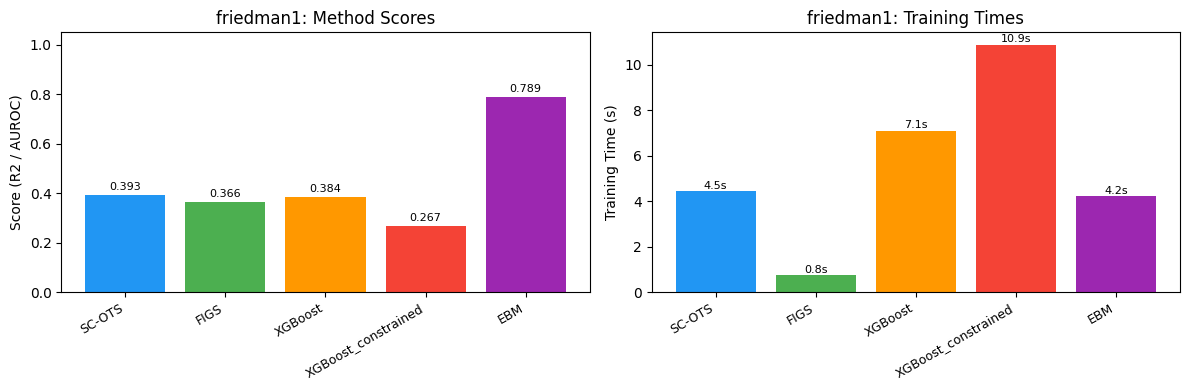


Total experiment time: 137.2s


In [15]:
methods = ["SC-OTS", "FIGS", "XGBoost", "XGBoost_constrained", "EBM"]

for ds_name, ds_result in results.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name} ({ds_result['task_type']})")
    print(f"{'='*60}")

    # Collect scores and times across folds
    method_scores = {m: [] for m in methods}
    method_times = {m: [] for m in methods}

    for fold_key, fold_data in ds_result["folds"].items():
        for m in methods:
            md = fold_data.get(m, {})
            method_scores[m].append(md.get("score", 0.0))
            method_times[m].append(md.get("training_time_s", 0.0))

    # Results table
    table_data = []
    for m in methods:
        scores = method_scores[m]
        times = method_times[m]
        mean_s = np.mean(scores) if scores else 0.0
        std_s = np.std(scores) if scores else 0.0
        mean_t = np.mean(times) if times else 0.0
        table_data.append([m, f"{mean_s:.4f}", f"{std_s:.4f}", f"{mean_t:.1f}s"])

    print("\nMethod Comparison:")
    print(tabulate(table_data, headers=["Method", "Score", "Std", "Time"],
                   tablefmt="simple"))

    # SC-OTS topological metadata
    for fold_key, fold_data in ds_result["folds"].items():
        scots = fold_data.get("SC-OTS", {})
        if scots.get("betti_numbers"):
            bn = scots["betti_numbers"]
            sc = scots.get("simplex_counts", {})
            print(f"\nTopological Metadata (fold {fold_key}):")
            print(f"  Betti numbers: b0={bn.get('b0',0)}, b1={bn.get('b1',0)}, b2={bn.get('b2',0)}")
            print(f"  Simplex counts: dim0={sc.get('dim_0',0)}, dim1={sc.get('dim_1',0)}, "
                  f"dim2={sc.get('dim_2',0)}, dim3={sc.get('dim_3',0)}")
            print(f"  Persistence threshold: {scots.get('persistence_threshold', 0.0):.4f}")
            if scots.get("interaction_recovery"):
                ir = scots["interaction_recovery"]
                print(f"  Interaction recovery: P={ir['precision']:.4f}, R={ir['recall']:.4f}, F1={ir['f1']:.4f}")

    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    mean_scores = [np.mean(method_scores[m]) for m in methods]
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
    axes[0].bar(range(len(methods)), mean_scores, color=colors)
    axes[0].set_xticks(range(len(methods)))
    axes[0].set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
    axes[0].set_ylabel("Score (R2 / AUROC)")
    axes[0].set_title(f"{ds_name}: Method Scores")
    axes[0].set_ylim(0, 1.05)
    for i, v in enumerate(mean_scores):
        axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=8)

    mean_times = [np.mean(method_times[m]) for m in methods]
    axes[1].bar(range(len(methods)), mean_times, color=colors)
    axes[1].set_xticks(range(len(methods)))
    axes[1].set_xticklabels(methods, rotation=30, ha='right', fontsize=9)
    axes[1].set_ylabel("Training Time (s)")
    axes[1].set_title(f"{ds_name}: Training Times")
    for i, v in enumerate(mean_times):
        axes[1].text(i, v + 0.1, f"{v:.1f}s", ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig("results.png", dpi=100, bbox_inches='tight')
    plt.show()

print(f"\nTotal experiment time: {total_time:.1f}s")